# 研究架构分组对比实验（seed=1442）

本 Notebook 对照“降维处理 → 空间特征提取与融合 → 分类方法”研究架构，读取已经
完成的真实结果，不重新训练或用测试集选模。四组实验分别控制降维方式、空间特征、
分类器和传统/深度学习范式。

统一协议：Pavia University、`fair24_6_70`、split/model seed 均为 1442；统计
预处理仅在训练中心像元拟合。


## 1. 读取完整实验


In [1]:
from pathlib import Path
import json
import shutil

import numpy as np
import pandas as pd
from IPython.display import Image, display

def find_project_root(start: Path) -> Path:
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / 'pyproject.toml').is_file():
            return candidate
    raise FileNotFoundError('Cannot locate 实验交付/pyproject.toml')

PROJECT_ROOT = find_project_root(Path.cwd())
candidates = sorted(
    (PROJECT_ROOT / 'experiments').glob(
        'hsi_architecture_comparison__fair24_6_70__seed1442__*'
    ), reverse=True,
)
RUN_DIR = next(
    (path for path in candidates if (path / 'status.json').is_file()
     and json.loads((path / 'status.json').read_text(encoding='utf-8')).get('status') == 'complete'),
    None,
)
if RUN_DIR is None:
    raise FileNotFoundError('No complete architecture comparison run was found.')

summary = pd.read_csv(RUN_DIR / 'summary.csv', encoding='utf-8-sig')
groups = json.loads((RUN_DIR / 'group_definitions.json').read_text(encoding='utf-8'))
assert len(summary) == 10
assert set(summary['method_key'].str.split('_').str[0]) == {
    'R1', 'R2', 'R3', 'S1', 'S2', 'S3', 'C1', 'D1', 'D2', 'D3'
}
print('正式运行：', RUN_DIR.relative_to(PROJECT_ROOT))
print('方法数：', len(summary), '；统一 seed=1442')


正式运行： experiments\hsi_architecture_comparison__fair24_6_70__seed1442__20260817-1330
方法数： 10 ；统一 seed=1442


## 2. 从研究架构到控制变量分组


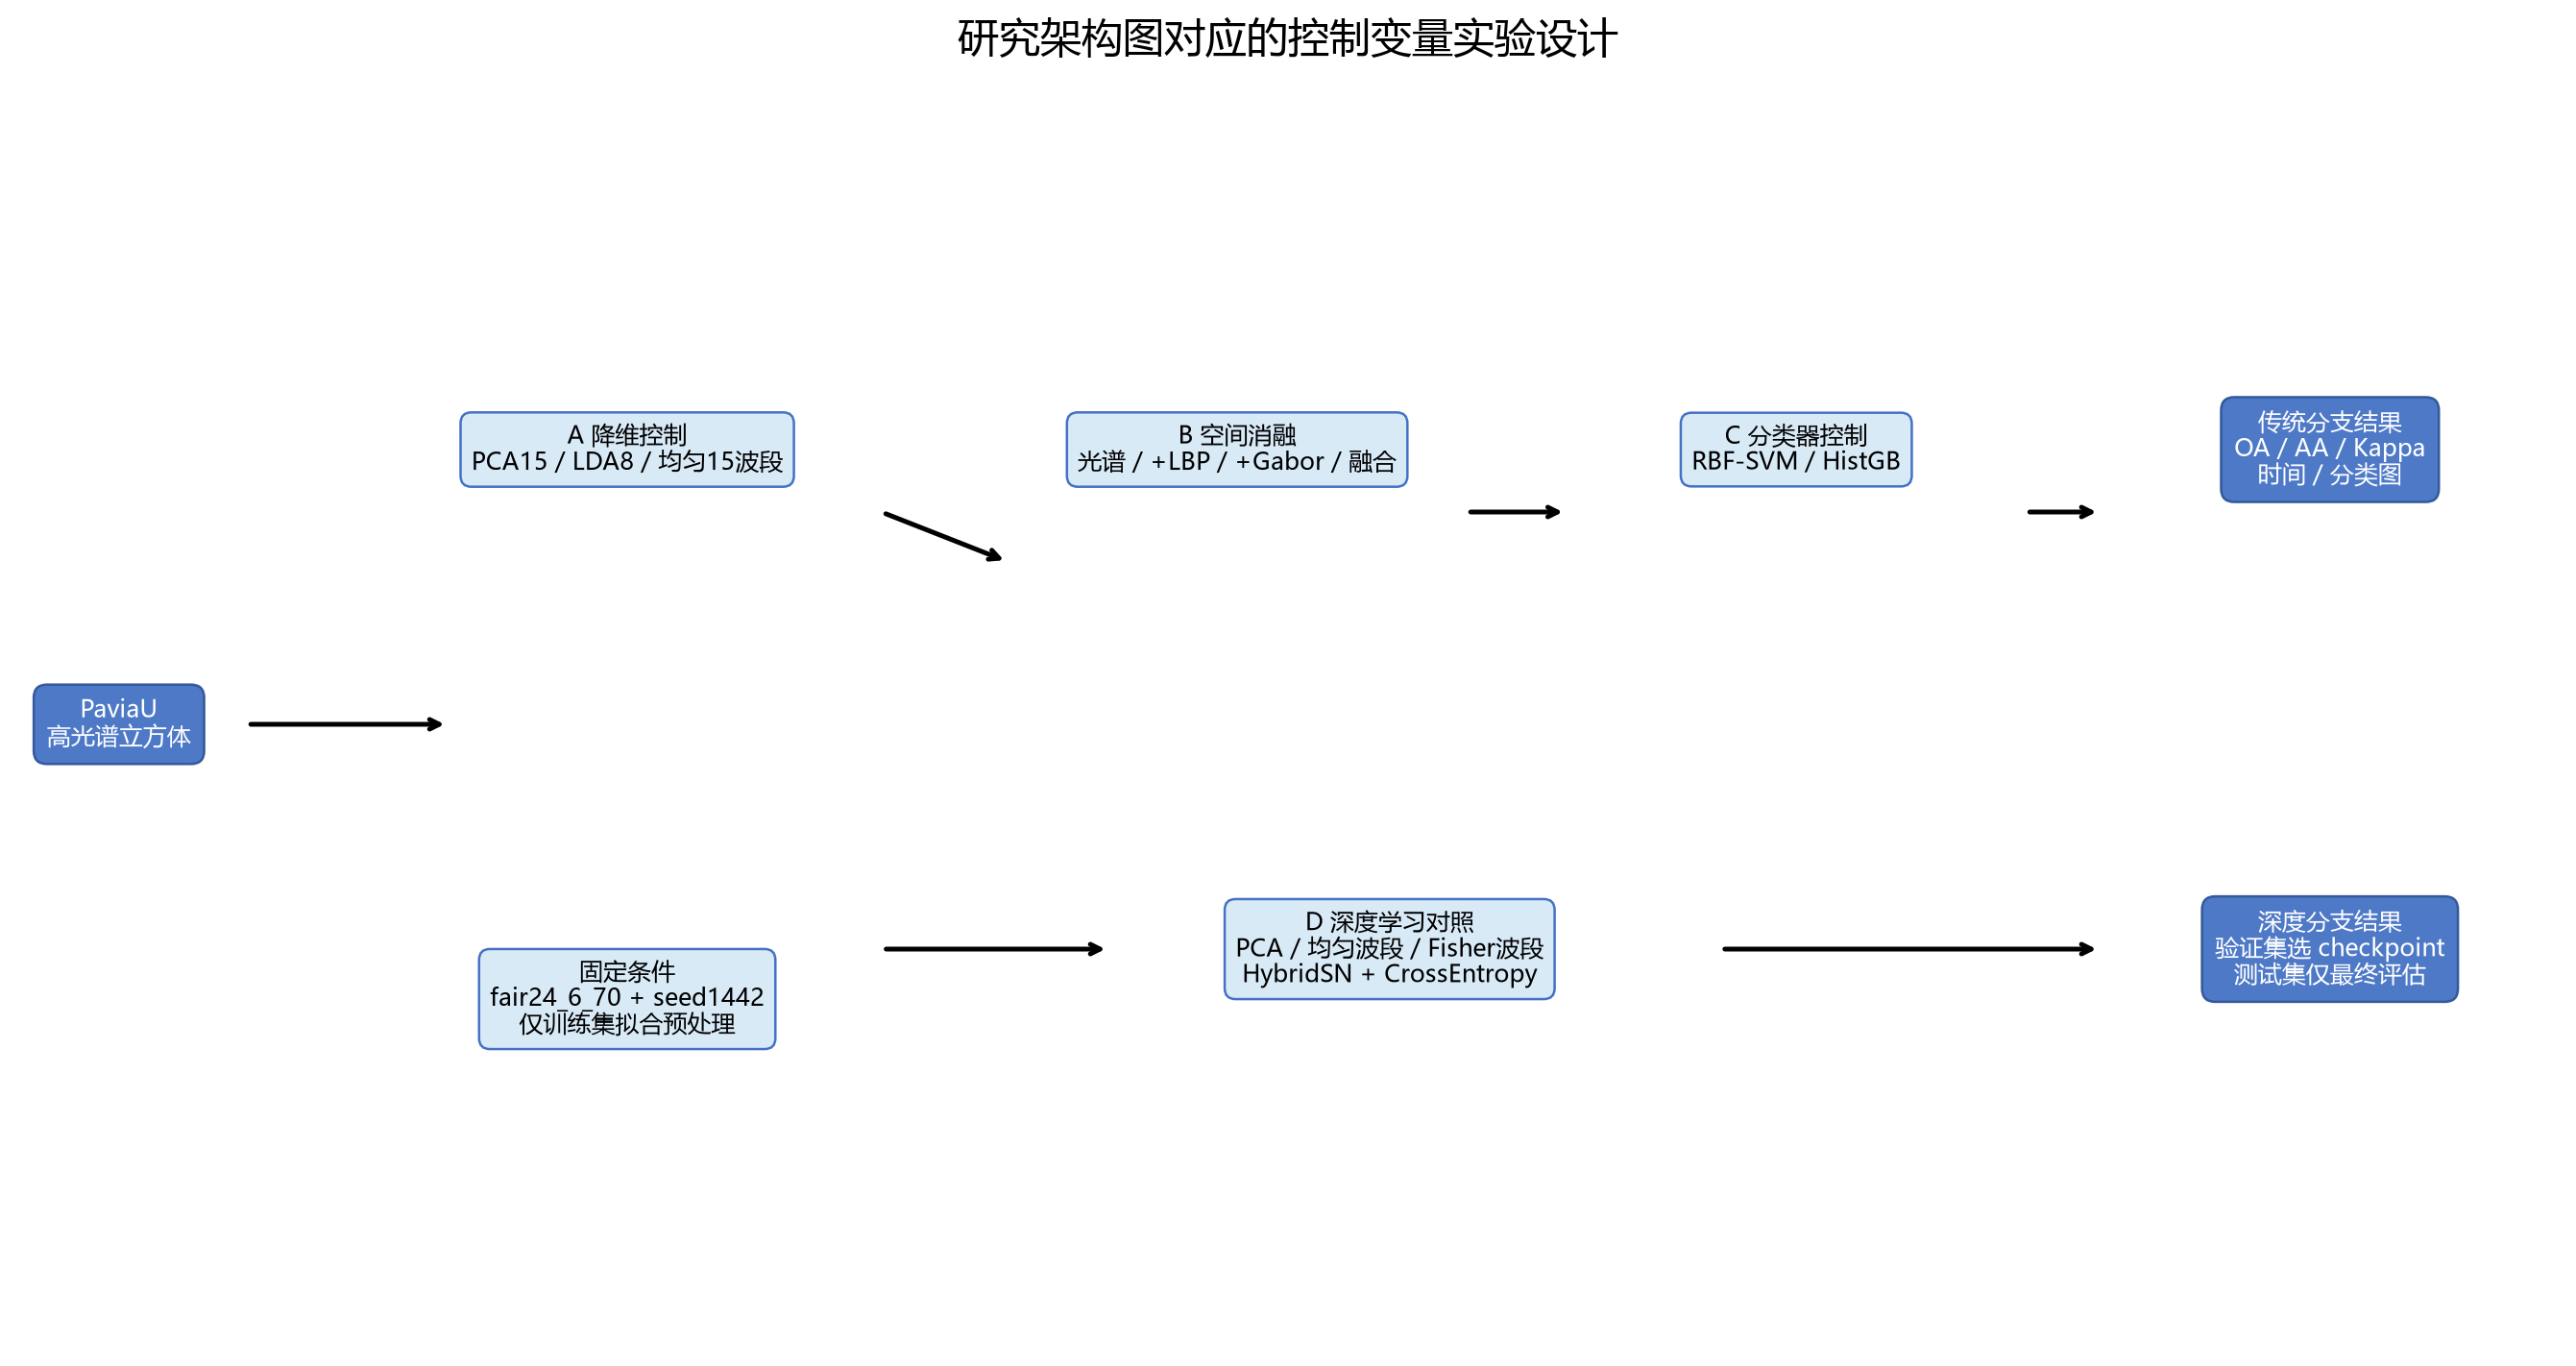

In [2]:
display(Image(filename=str(RUN_DIR / 'architecture_group_design.png'), width=1200))


- **A 降维组：**固定光谱中心像元特征与 RBF-SVM，只换 PCA15、LDA8、均匀15波段。
- **B 空间组：**固定 PCA15 与 RBF-SVM，只换无空间、LBP、Gabor、LBP+Gabor。
- **C 分类器组：**固定 111 维 PCA15+LBP+Gabor，只换 SVM 与 HistGradientBoosting。
- **D 范式组：**在同一划分/种子上对照传统方法和 25×25 patch 的 HybridSN。


## 3. 十种方法结果总表


In [3]:
table = summary[[
    'method_key', 'display_name', 'feature_dimension', 'validation_oa',
    'test_oa', 'test_aa', 'test_kappa', 'test_errors',
    'training_seconds', 'test_inference_seconds',
]].copy()
table.columns = [
    '编号', '方法', '特征维数', 'Validation OA', 'Test OA', 'Test AA',
    'Kappa', '错分像元', '训练时间(s)', '测试推理(s)',
]
formatted_table = table.copy()
for column in ('Validation OA', 'Test OA', 'Test AA'):
    formatted_table[column] = formatted_table[column].map(lambda value: f'{value:.4%}')
formatted_table['Kappa'] = formatted_table['Kappa'].map(lambda value: f'{value:.6f}')
formatted_table['训练时间(s)'] = formatted_table['训练时间(s)'].map(lambda value: f'{value:.3f}')
formatted_table['测试推理(s)'] = formatted_table['测试推理(s)'].map(lambda value: f'{value:.3f}')
display(formatted_table)

validation_best = summary.sort_values(
    ['validation_oa', 'method_key'], ascending=[False, True]
).iloc[0]
test_best = summary.sort_values(
    ['test_oa', 'method_key'], ascending=[False, True]
).iloc[0]
print(f"验证集选择：{validation_best['display_name']}，Val OA={validation_best['validation_oa']:.4%}")
print(f"测试集数值最高：{test_best['display_name']}，Test OA={test_best['test_oa']:.4%}（仅描述）")


,编号,方法,特征维数,Validation OA,Test OA,Test AA,Kappa,错分像元,训练时间(s),测试推理(s)
0,R1_PCA15_SVM,PCA15 + SVM,15,94.1956%,93.7016%,91.3993%,0.916289,1886,17.787,32.641
1,R2_LDA8_SVM,LDA8 + SVM,8,91.4297%,91.3438%,88.8494%,0.884856,2592,11.459,23.287
2,R3_Uniform15_SVM,均匀15波段 + SVM,15,90.7285%,90.3620%,87.4884%,0.870633,2886,6.199,31.977
3,S1_PCA15_LBP_SVM,PCA15 + LBP + SVM,63,99.4936%,99.5124%,99.3337%,0.993531,146,33.604,58.079
4,S2_PCA15_Gabor_SVM,PCA15 + Gabor + SVM,63,99.6494%,99.5692%,99.5332%,0.994291,129,22.098,32.895
5,S3_PCA15_LBP_Gabor_SVM,PCA15 + LBP + Gabor + SVM,111,99.9610%,99.9365%,99.9212%,0.999159,19,32.547,52.539
6,C1_PCA15_LBP_Gabor_HistGB,PCA15 + LBP + Gabor + HistGB,111,99.3377%,99.3755%,98.9893%,0.991723,187,62.787,4.548
7,D1_PCA15_HybridSN,PCA15 + HybridSN,9375,100.0000%,99.9532%,99.9405%,0.999381,14,125.789,2.453
8,D2_Uniform15_HybridSN,均匀15波段 + HybridSN,9375,99.9221%,99.9299%,99.8790%,0.999071,21,124.922,2.271
9,D3_Fisher15_HybridSN,Fisher15波段 + HybridSN,9375,99.7273%,99.7095%,99.4775%,0.996151,87,178.037,5.133


验证集选择：PCA15 + HybridSN，Val OA=100.0000%
测试集数值最高：PCA15 + HybridSN，Test OA=99.9532%（仅描述）


## 4. 四组主结果


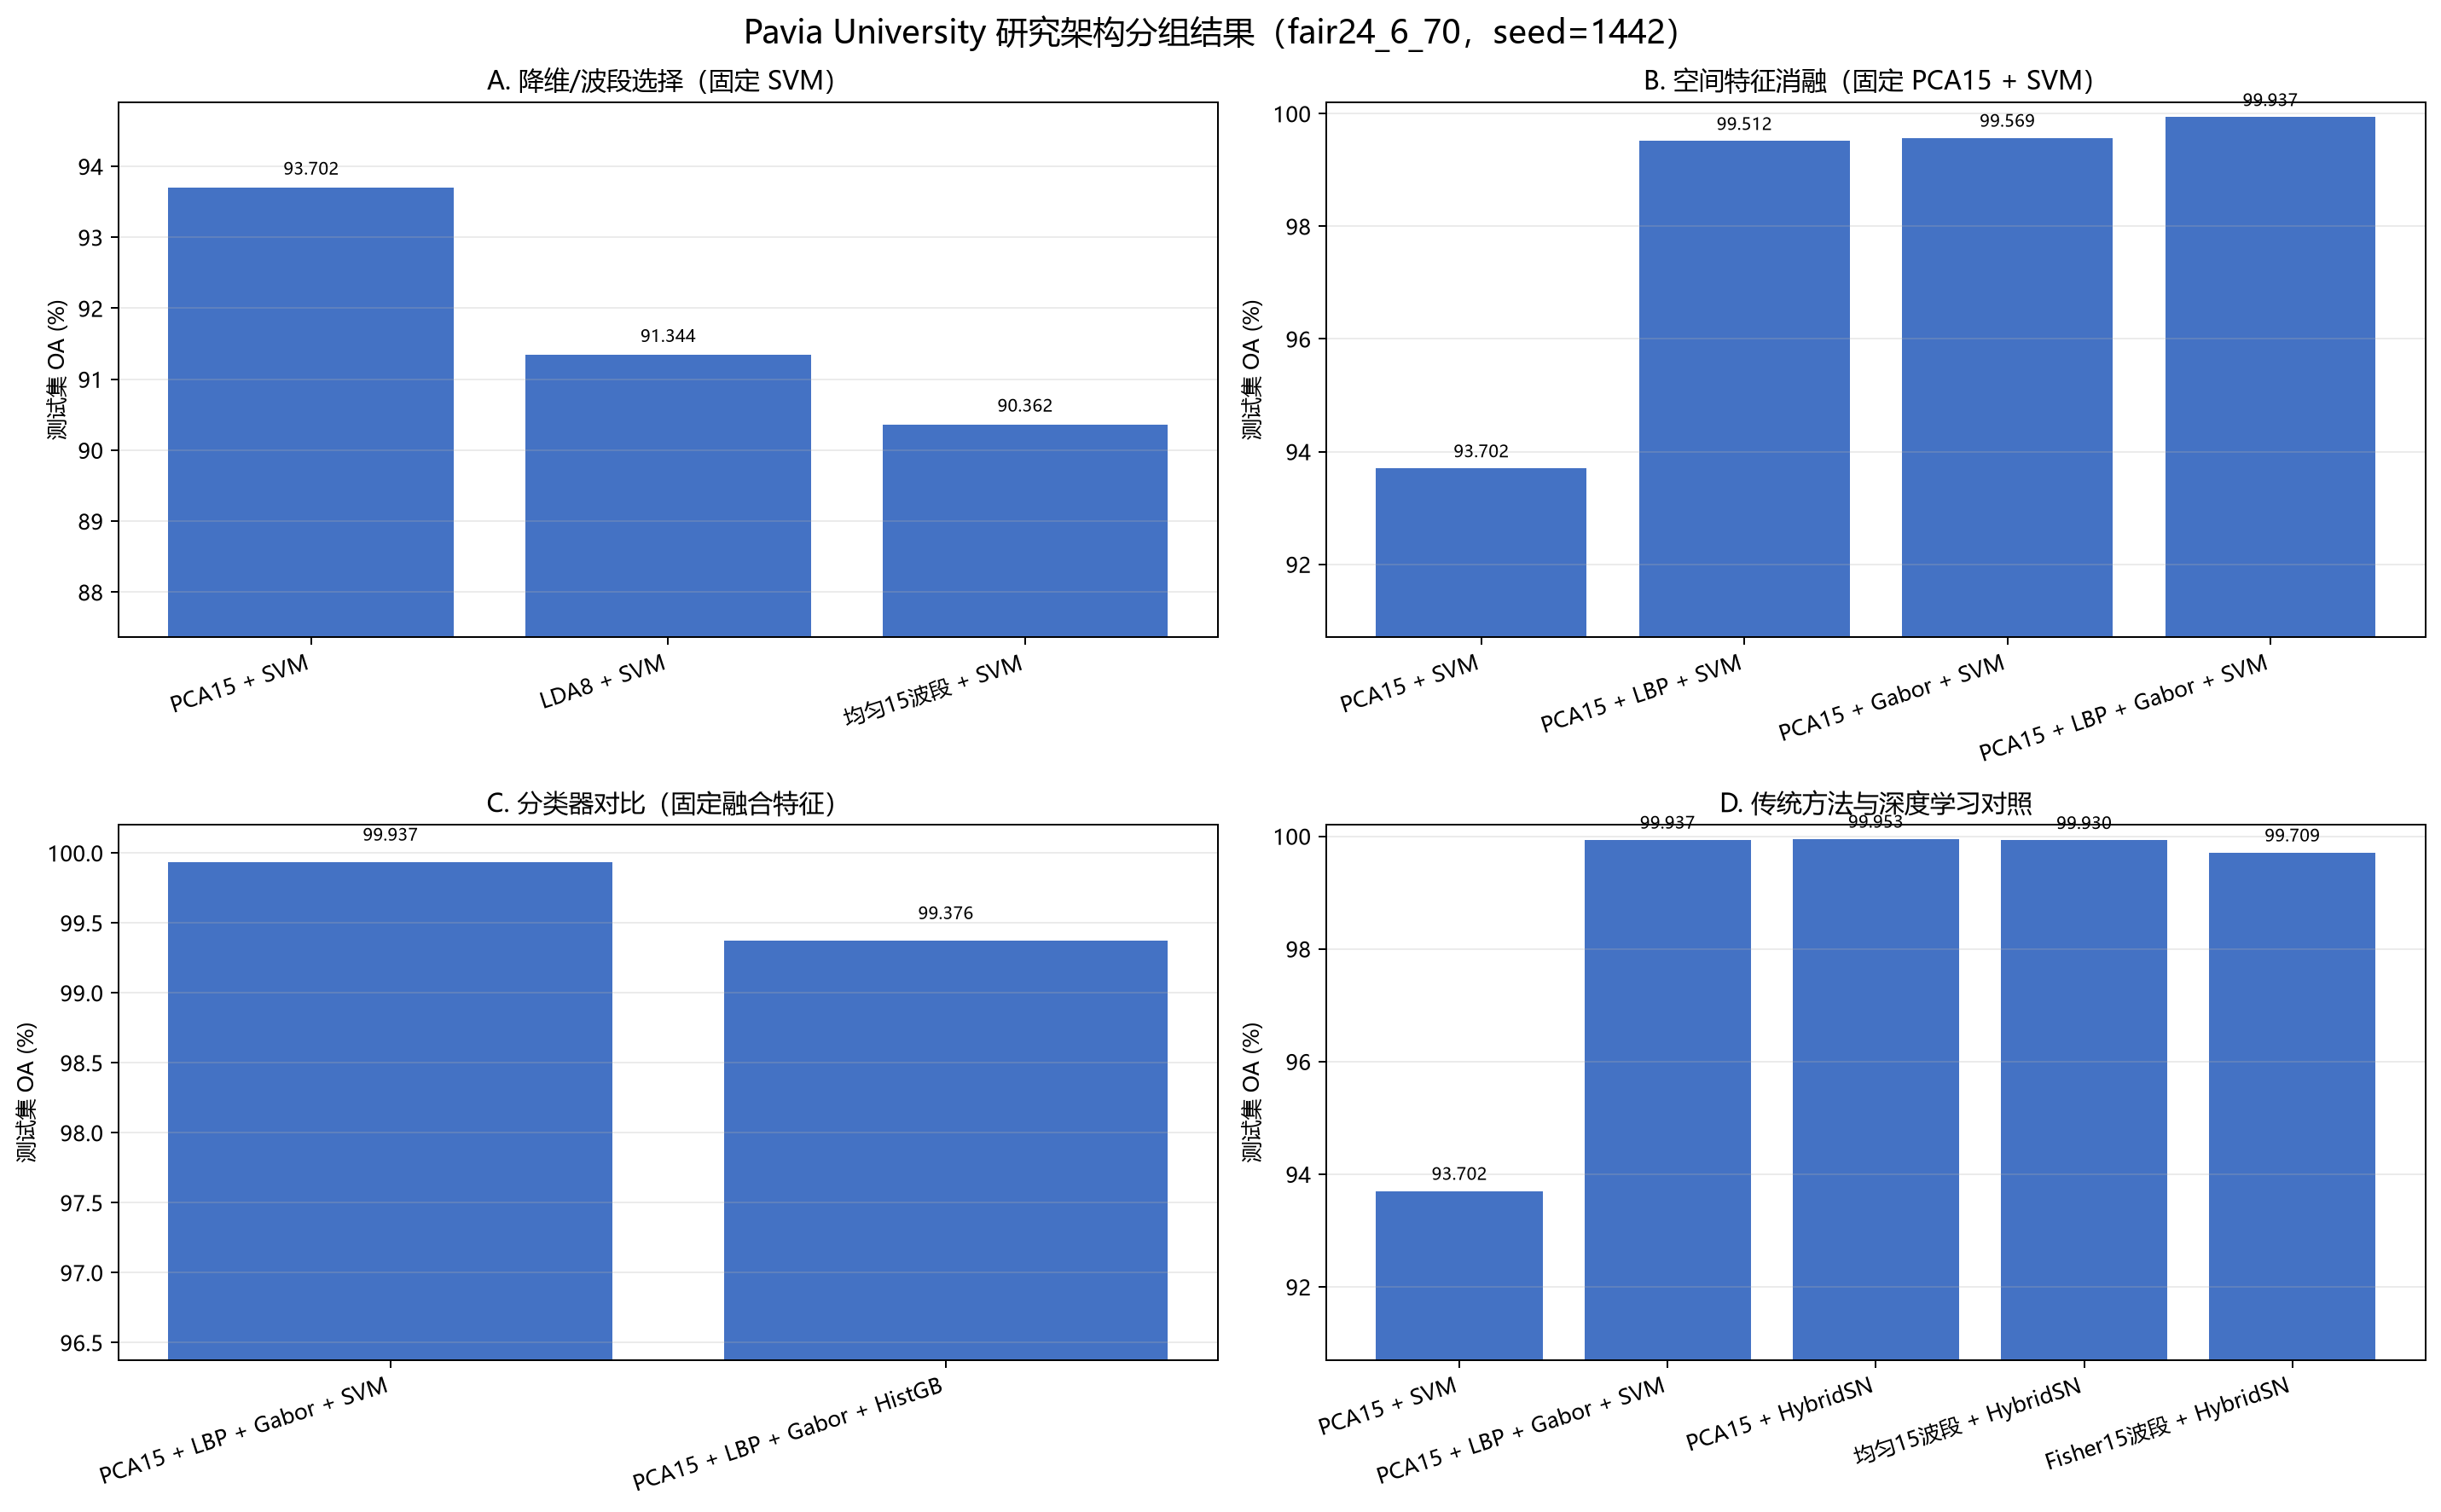

In [4]:
display(Image(filename=str(RUN_DIR / 'group_comparison_metrics.png'), width=1250))


In [5]:
lookup = summary.set_index('method_key')
def delta(left, right):
    return (lookup.loc[right, 'test_oa'] - lookup.loc[left, 'test_oa']) * 100

analysis = pd.DataFrame([
    {'比较': 'LDA8 vs PCA15（固定 SVM）', 'Test OA变化/百分点': delta('R1_PCA15_SVM', 'R2_LDA8_SVM')},
    {'比较': '均匀15波段 vs PCA15（固定 SVM）', 'Test OA变化/百分点': delta('R1_PCA15_SVM', 'R3_Uniform15_SVM')},
    {'比较': '加入 LBP', 'Test OA变化/百分点': delta('R1_PCA15_SVM', 'S1_PCA15_LBP_SVM')},
    {'比较': '加入 Gabor', 'Test OA变化/百分点': delta('R1_PCA15_SVM', 'S2_PCA15_Gabor_SVM')},
    {'比较': '融合 LBP+Gabor', 'Test OA变化/百分点': delta('R1_PCA15_SVM', 'S3_PCA15_LBP_Gabor_SVM')},
    {'比较': 'HistGB vs SVM（固定融合特征）', 'Test OA变化/百分点': delta('S3_PCA15_LBP_Gabor_SVM', 'C1_PCA15_LBP_Gabor_HistGB')},
    {'比较': 'HybridSN vs 手工融合 SVM', 'Test OA变化/百分点': delta('S3_PCA15_LBP_Gabor_SVM', 'D1_PCA15_HybridSN')},
])
formatted_analysis = analysis.copy()
formatted_analysis['Test OA变化/百分点'] = formatted_analysis['Test OA变化/百分点'].map(
    lambda value: f'{value:+.3f}'
)
display(formatted_analysis)


,比较,Test OA变化/百分点
0,LDA8 vs PCA15（固定 SVM）,-2.358
1,均匀15波段 vs PCA15（固定 SVM）,-3.340
2,加入 LBP,+5.811
3,加入 Gabor,+5.868
4,融合 LBP+Gabor,+6.235
5,HistGB vs SVM（固定融合特征）,-0.561
6,HybridSN vs 手工融合 SVM,+0.017


主要观察：PCA15 是三种传统光谱表示中最强；LBP/Gabor 空间信息把纯光谱 SVM
从 93.70% 提高到 99.5% 以上，融合后达到 99.9365%。HybridSN 测试 OA 为
99.9532%，只比手工融合 SVM 高 0.0167 个百分点，但其 GPU 批量推理更快。


## 5. 逐类别结果与分类图


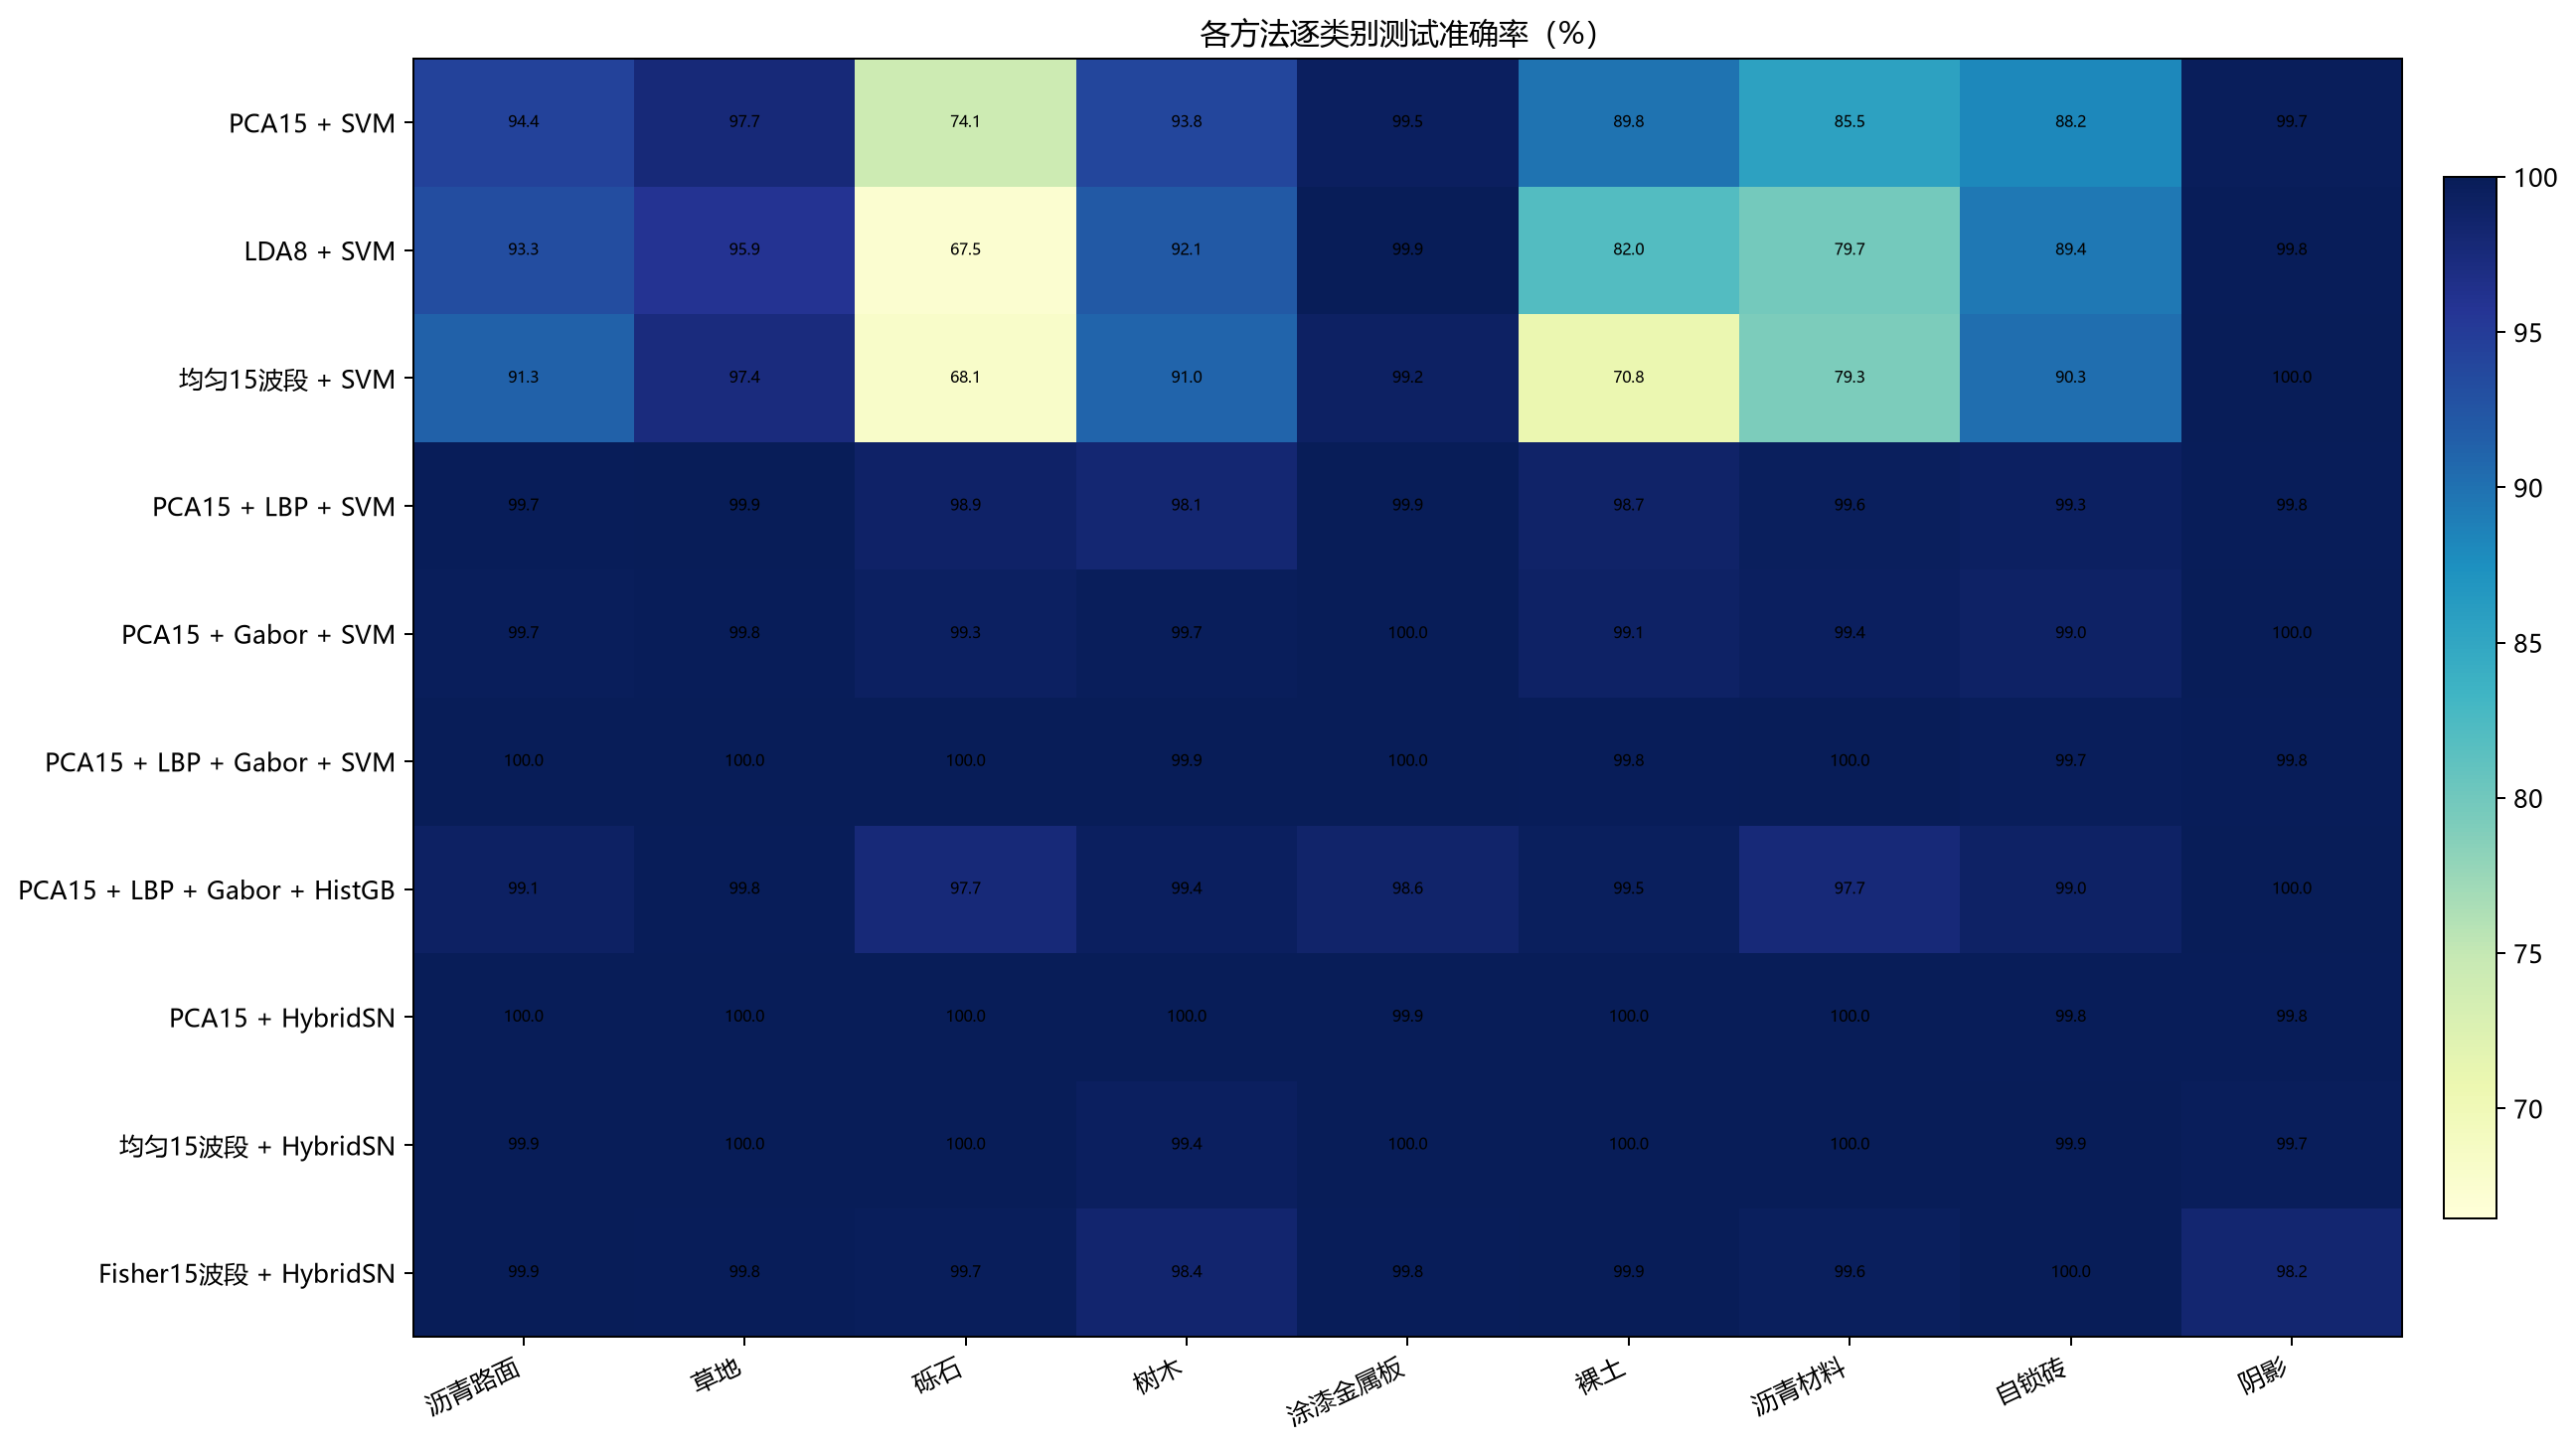

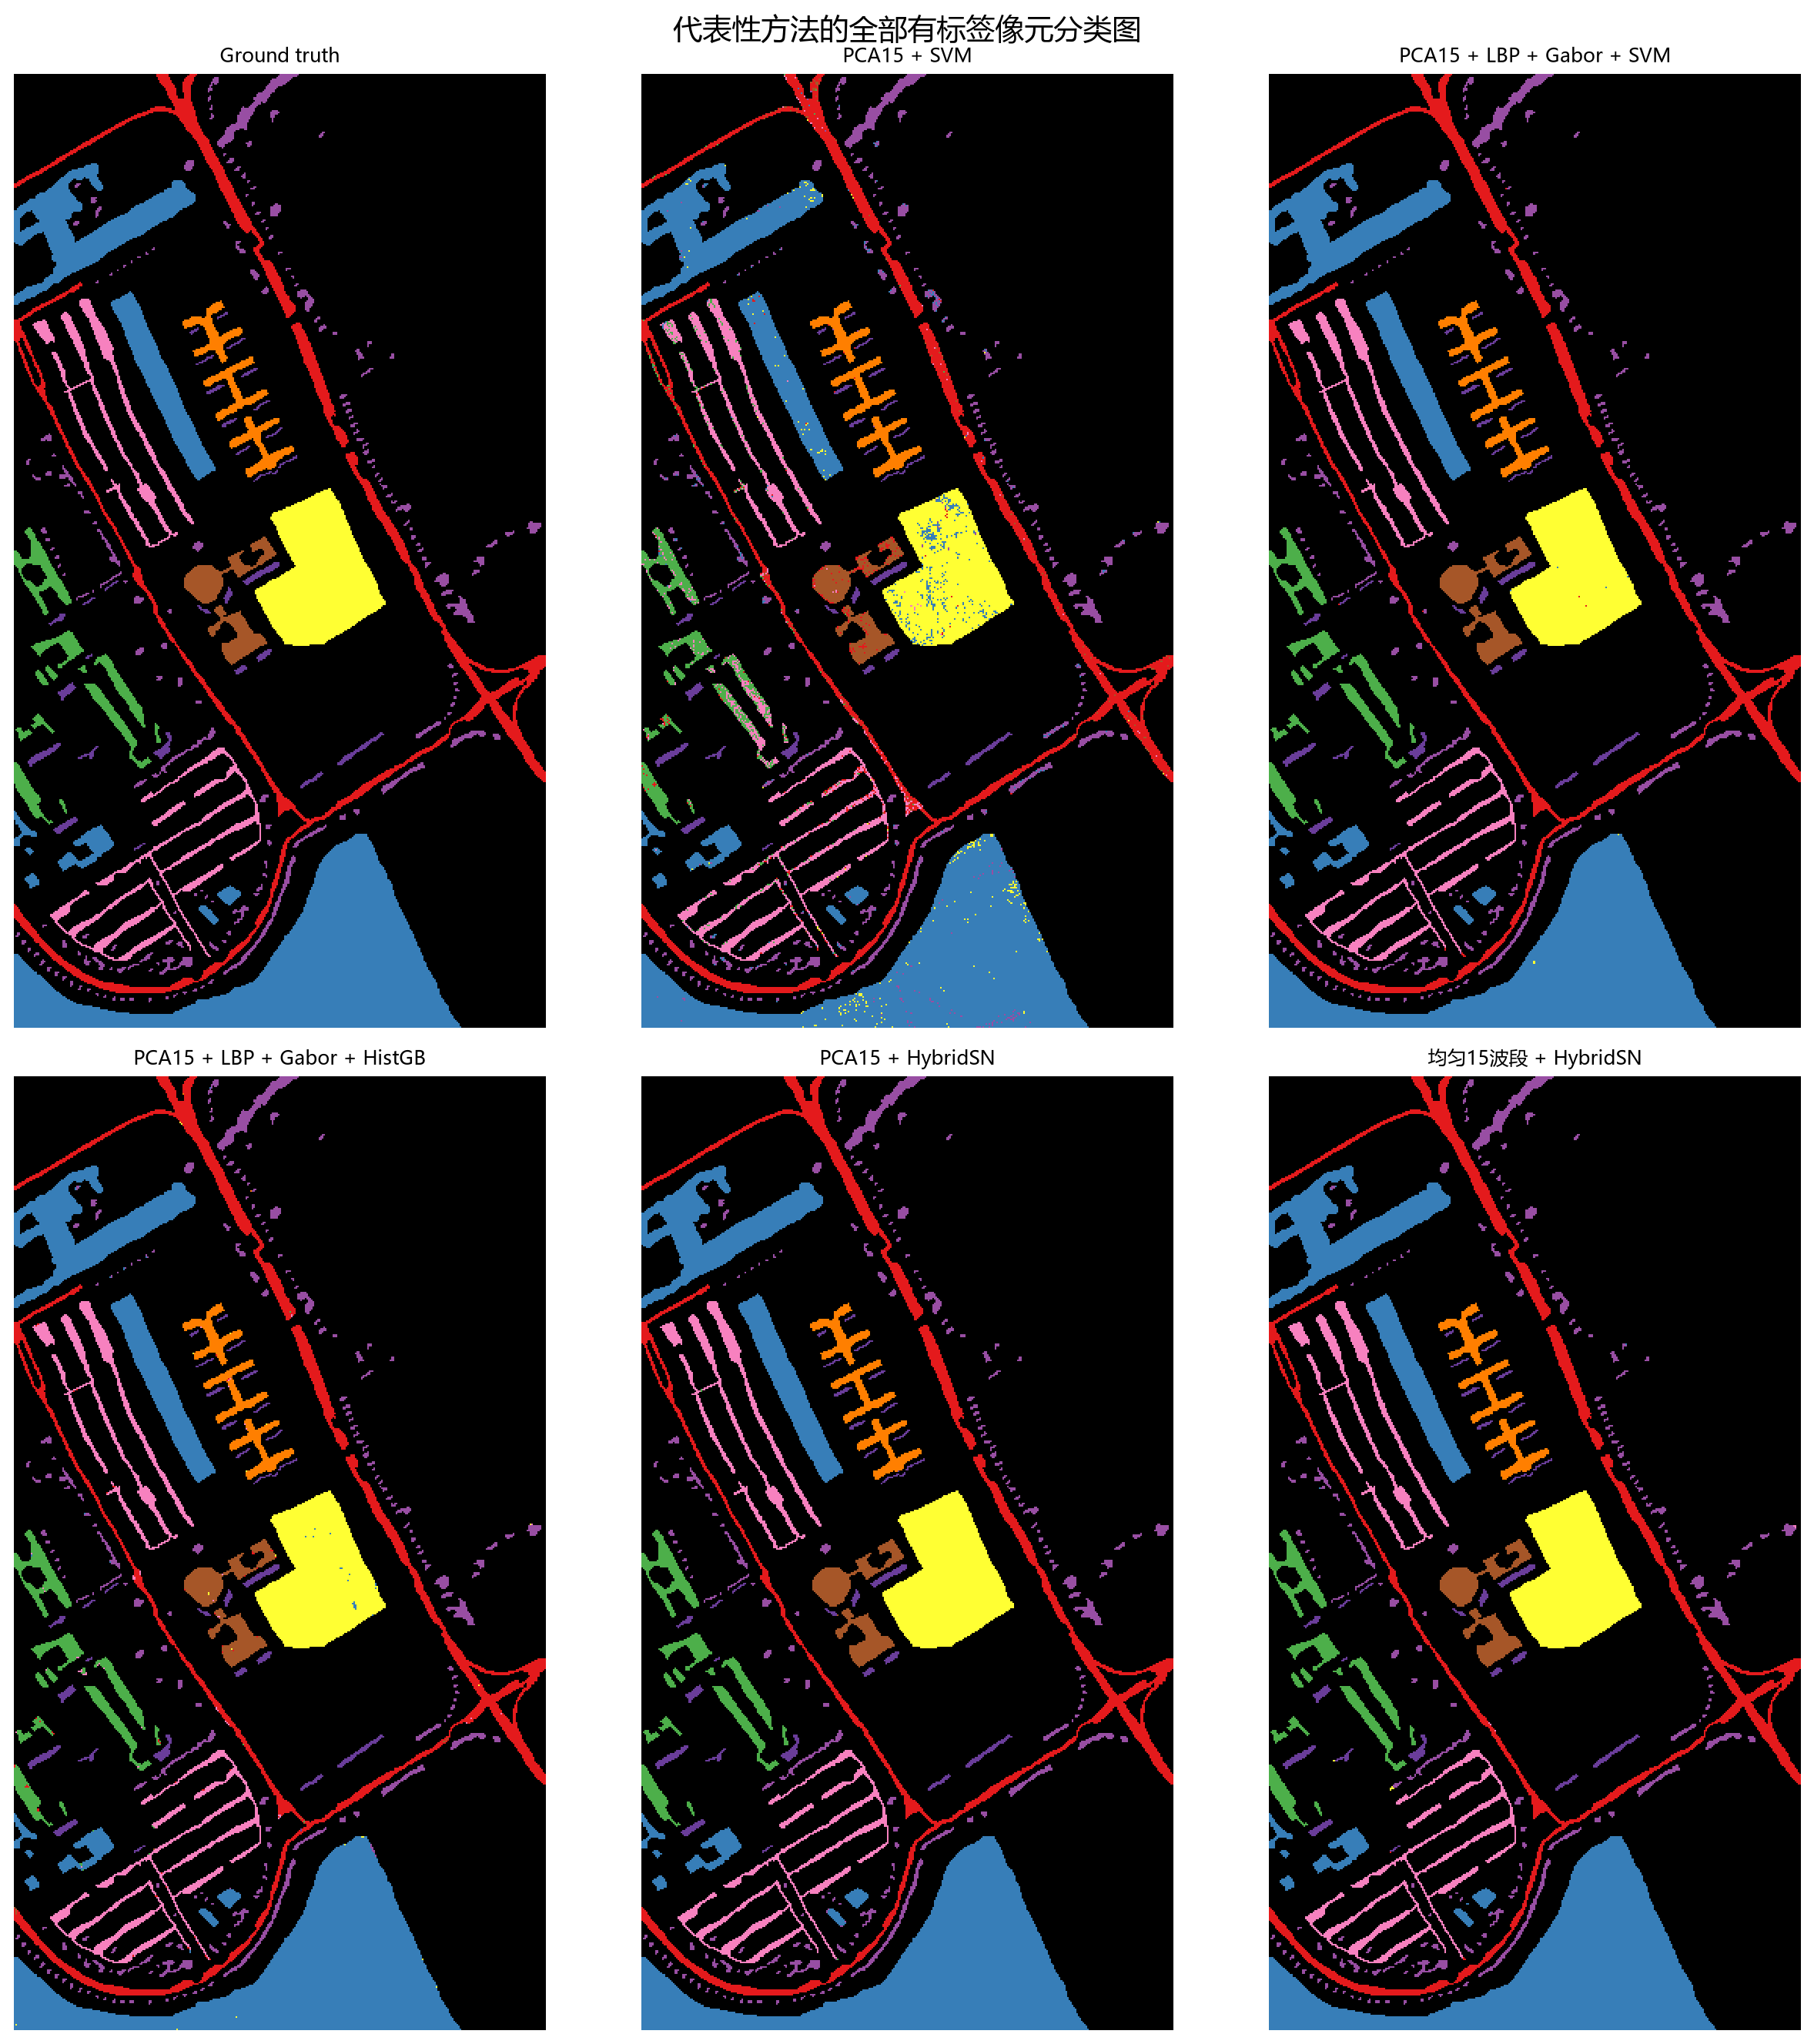

In [6]:
display(Image(filename=str(RUN_DIR / 'per_class_accuracy_heatmap.png'), width=1250))
display(Image(filename=str(RUN_DIR / 'representative_classification_maps.png'), width=1250))


黑色区域是 Ground Truth 未标注像元，不是模型预测的第十类。分类图回填的是
42,776 个有标签像元；OA/AA/Kappa 只在冻结的 29,944 个测试像元上计算。纯光谱
PCA-SVM 有明显椒盐错误，引入空间纹理后区域一致性大幅改善。


## 6. 精度—成本权衡


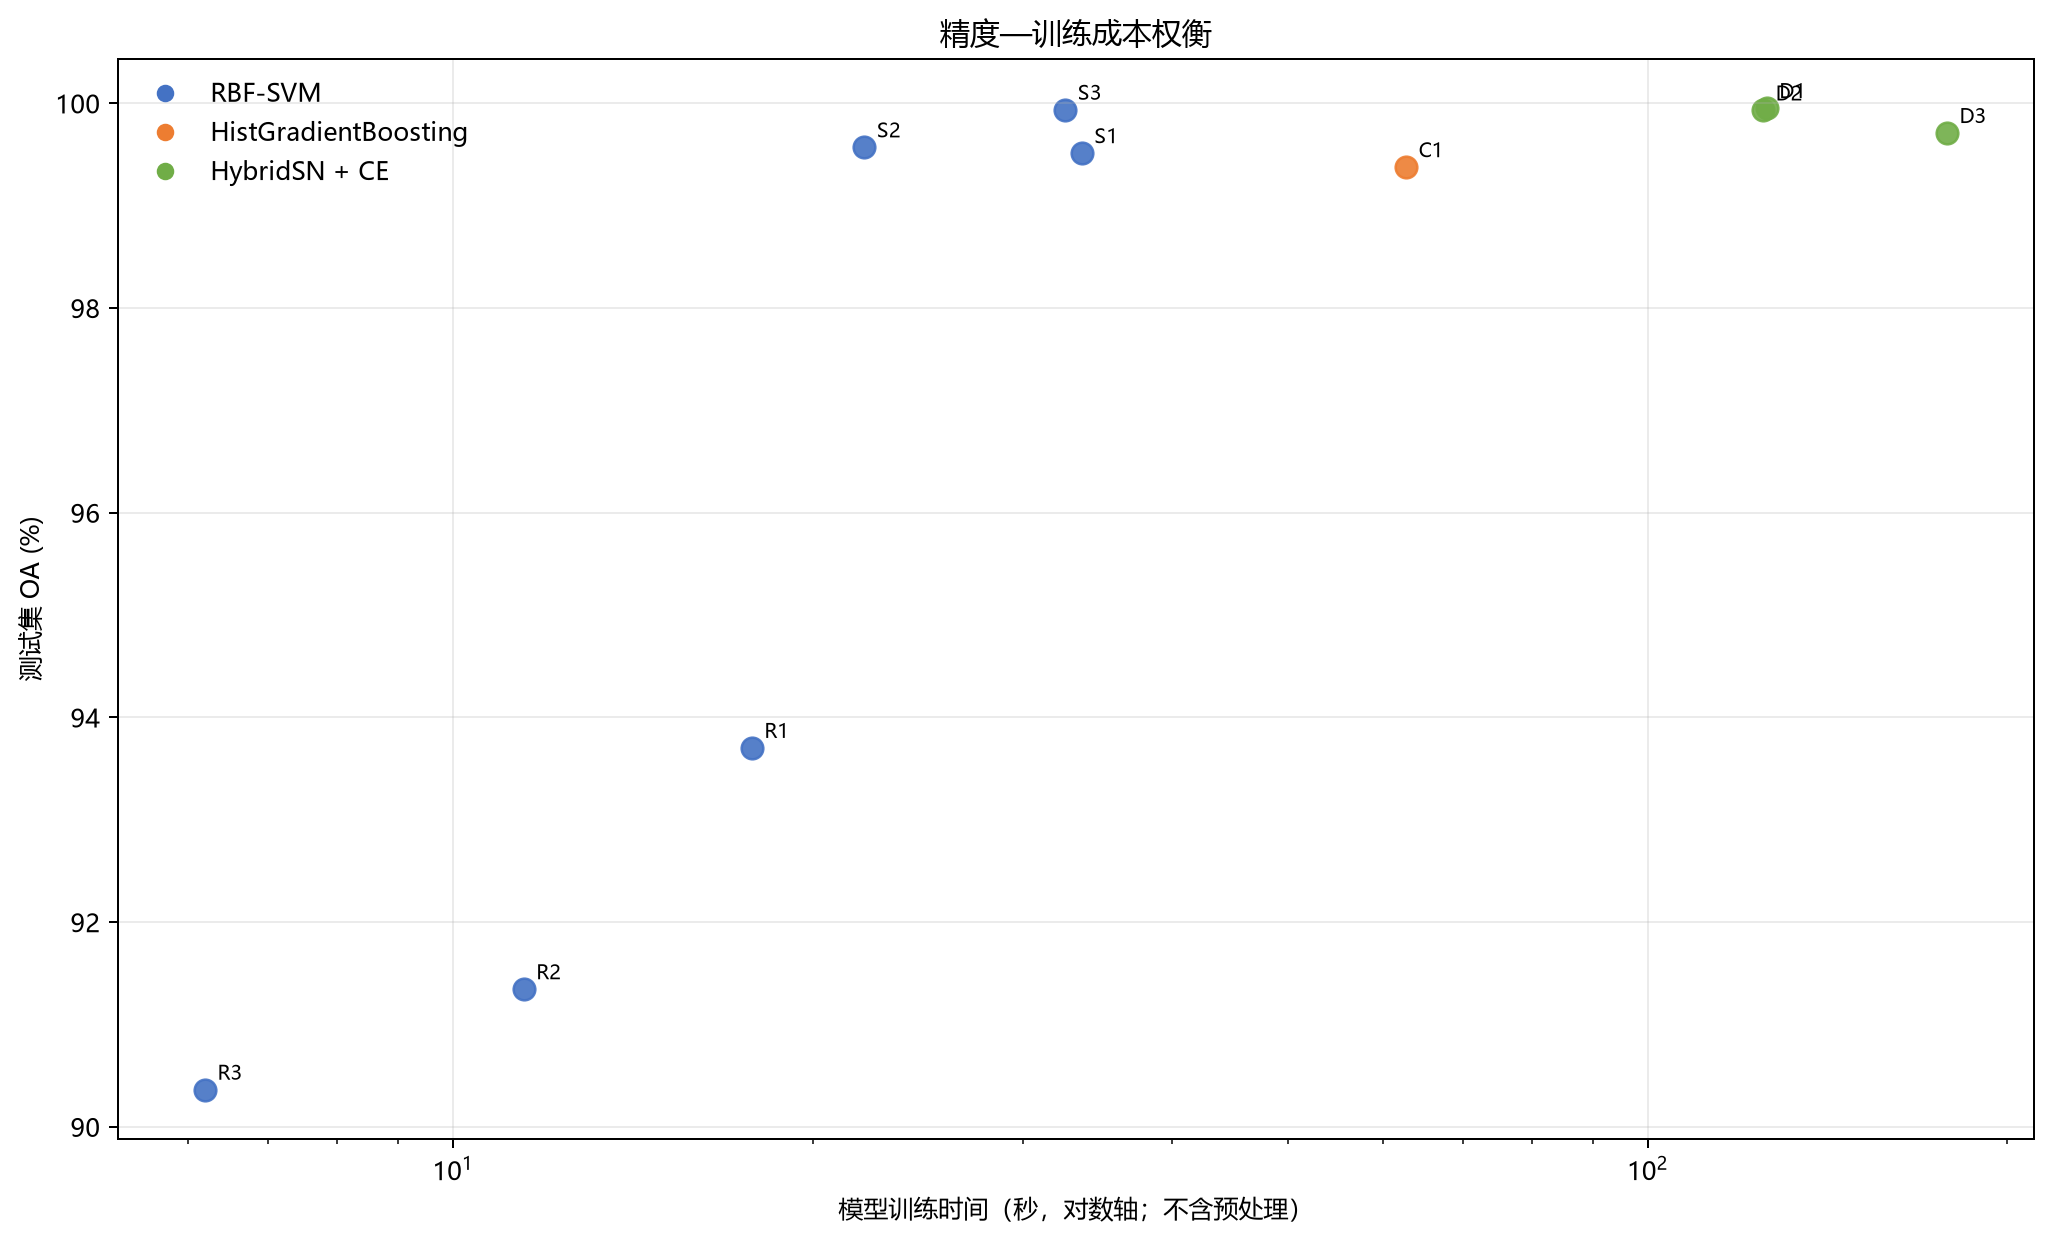

In [7]:
display(Image(filename=str(RUN_DIR / 'accuracy_efficiency_tradeoff.png'), width=1000))


训练时间不含预处理，且传统模型在 CPU、HybridSN 在 GPU 上执行，因此跨硬件
时间只能表示本机工程成本，不能当作算法复杂度的绝对结论。HistGB 测试推理快，但
精度和训练时间均不及融合 SVM；HybridSN 参数量约 484 万，批量推理吞吐更高。


## 7. 任务性质与 Softmax/Sigmoid


PaviaU 是 `610×340×103` 高光谱影像立方体，不是点云；每个二维像元拥有
103 维光谱。当前推理目标是给中心像元分配一个互斥地物类别。HybridSN 一次接收
`1×15×25×25` patch，输出中心像元一个 9 类结果，多坐标回填后才形成分类图。

因此它是**光谱—空间逐像元分类 / patch-to-one-label classification**。输出图像看似
语义分割，但网络并非 U-Net/FCN 式整图到整图的端到端密集分割。

九类互斥，所以 `CrossEntropyLoss` 对应 Softmax 多分类；Sigmoid 假设各类相互独立，
适合多标签任务，不应作为本课题主分类头。


## 8. 局限与改进优先级


In [8]:
overlap = json.loads((RUN_DIR / 'spatial_overlap_audit_patch9.json').read_text(encoding='utf-8'))
overlap_table = pd.DataFrame([{
    '空间窗口': '9×9（LBP/Gabor pooling）',
    '测试窗口含训练中心': overlap['any_training_center_in_query_patch']['fraction_with_at_least_one'],
    '测试窗口含同类训练中心': overlap['same_class_training_center_in_query_patch']['fraction_with_at_least_one'],
    '每窗口训练中心中位数': overlap['any_training_center_in_query_patch']['median'],
}])
formatted_overlap = overlap_table.copy()
for column in ('测试窗口含训练中心', '测试窗口含同类训练中心'):
    formatted_overlap[column] = formatted_overlap[column].map(lambda value: f'{value:.4%}')
formatted_overlap['每窗口训练中心中位数'] = formatted_overlap['每窗口训练中心中位数'].map(
    lambda value: f'{value:.1f}'
)
display(formatted_overlap)


,空间窗口,测试窗口含训练中心,测试窗口含同类训练中心,每窗口训练中心中位数
0,9×9（LBP/Gabor pooling）,99.6126%,99.5158%,14.0


1. 首先增加空间块/连通区域划分，检验高分是否能跨区域保持；随机像元划分存在强空间相关。
2. 安装 `xgboost` 后补做真正的 XGBoost；本表 C1 是 sklearn HistGradientBoosting，报告中不能写成 XGBoost。
3. 仅用 validation 对 SVM C/gamma、LBP 窗口与 Gabor 频率做小网格，test 保持一次最终评估。
4. 最终结论增加同一组 3–5 个种子的均值±标准差；本轮按课程要求统一 seed1442。
5. HybridSN 后续比较轻量卷积、BatchNorm/残差/注意力，并同步报告参数、显存、训练与推理吞吐。


## 9. 导出 Word 报告素材


In [9]:
REPORT_DIR = PROJECT_ROOT / 'results/notebook_outputs/reference_aligned/architecture_comparison'
REPORT_DIR.mkdir(parents=True, exist_ok=True)
for filename in (
    'summary.csv', 'summary.json', '实验记录.md', 'architecture_group_design.png',
    'group_comparison_metrics.png', 'accuracy_efficiency_tradeoff.png',
    'per_class_accuracy_heatmap.png', 'representative_classification_maps.png',
    'spatial_overlap_audit_patch9.json',
):
    shutil.copy2(RUN_DIR / filename, REPORT_DIR / filename)
for method in ('S3_PCA15_LBP_Gabor_SVM', 'C1_PCA15_LBP_Gabor_HistGB'):
    for filename in ('confusion_matrix.png', 'per_class_accuracy.png', 'classification_map.png'):
        shutil.copy2(RUN_DIR / method / filename, REPORT_DIR / f'{method}__{filename}')
table.to_csv(REPORT_DIR / 'Word结果主表.csv', index=False, encoding='utf-8-sig')
analysis.to_csv(REPORT_DIR / '分组增益分析.csv', index=False, encoding='utf-8-sig')
print('报告素材目录：', REPORT_DIR)
print('文件数：', len(list(REPORT_DIR.iterdir())))


报告素材目录： G:\高光谱智能图像解译\实验交付\results\notebook_outputs\reference_aligned\architecture_comparison
文件数： 17
